# Notebook Instructions

1. If you are new to Jupyter notebooks, please go through this introductory manual <a href='https://quantra.quantinsti.com/quantra-notebook' target="_blank">here</a>.
1. Any changes made in this notebook would be lost after you close the browser window. **You can download the notebook to save your work on your PC.**
1. Before running this notebook on your local PC:<br>
i.  You need to set up a Python environment and the relevant packages on your local PC. To do so, go through the section on "**Run Codes Locally on Your Machine**" in the course.<br>
ii. You need to **download the zip file available in the last unit** of this course. The zip file contains the data files and/or python modules that might be required to run this notebook.

# FX value strategy

In this notebook, we will create a strategy using REER valuation. The notebook is structured as follows:
1. [Read the REER Data](#read)
2. [Generate Trading Signals](#signals)
3. [Import Currency Pairs Data](#currency)
4. [Compute Strategy Returns](#returns)
5. [Analyse Strategy Performance](#analyse)

<a id='read'></a> 
## Read the REER Data

Read the REER data from csv file and compute the rolling mean of REER for last 6 months. The REER data can be downloaded from the Bank for International Settlements (BIS) <a href="https://www.bis.org/statistics/eer.htm" target="_blank"> website</a>. We have used BIS effective exchange rate, Real (CPI-based), Narrow Indices, Monthly averages.

In [1]:
# Get the REER
import pandas as pd
import warnings 
warnings.filterwarnings('ignore')
reer = pd.read_csv('../data_modules/REER_2023_Aug2021_Jul2023.csv', index_col=0)
reer.index = pd.to_datetime(reer.index)
reer.tail()

,Australia,Canada,Euro area,Japan,New Zealand,Singapore,Switzerland,United Kingdom
2023-03-01,103.93,96.88,100.56,75.21,103.82,110.63,97.89,102.91
2023-04-01,102.91,98.02,102.00,74.80,102.83,110.12,98.54,104.40
2023-05-01,102.99,98.12,101.25,72.95,103.83,110.46,99.46,106.12
2023-06-01,104.27,99.50,101.01,70.48,102.59,110.48,99.06,107.48
2023-07-01,104.00,99.57,101.45,70.24,103.88,110.71,100.40,108.57


The syntax to compute the rolling mean is:<BR>
<font color=blue>dataframe.rolling(lookback).mean()</font>

Parameter:
1. dataframe is the name of the dataframe on which rolling mean is to be computed. It computes mean along the columns.
2. lookback is the length of price series on which to compute the mean

In [2]:
# Calculate the rolling mean of reer
reer_mean = reer.rolling(6).mean()

reer_mean.tail()

,Australia,Canada,Euro area,Japan,New Zealand,Singapore,Switzerland,United Kingdom
2023-03-01,105.566667,98.676667,99.186667,74.751667,103.956667,110.006667,97.733333,102.575000
2023-04-01,105.380000,98.451667,99.950000,75.198333,104.386667,110.273333,97.958333,103.071667
2023-05-01,104.943333,98.050000,100.425000,75.191667,104.365000,110.373333,98.310000,103.636667
2023-06-01,104.733333,98.258333,100.701667,74.333333,103.741667,110.460000,98.513333,104.211667
2023-07-01,104.225000,98.430000,101.013333,73.163333,103.533333,110.538333,98.953333,105.286667


<a id='signals'></a> 
## Generate the Trading Signal 
The strategy works as follows:
1. If REER value >= 6 months mean of the REER then <font color=red>sell</font> the currency pair <BR>
2. If REER value < 6 months mean of the REER then <font color=green>buy</font> the currency pair <BR>
    
Therefore, if REER is less than the rolling mean then set to True else set to False.

In [3]:
# Set the signal
signal = reer < reer_mean
signal.tail()

,Australia,Canada,Euro area,Japan,New Zealand,Singapore,Switzerland,United Kingdom
2023-03-01,True,True,False,False,True,False,False,False
2023-04-01,True,True,False,True,True,True,False,False
2023-05-01,True,False,False,True,True,False,False,False
2023-06-01,True,False,False,True,True,False,False,False
2023-07-01,True,False,False,True,False,False,False,False


To ease computation of strategy returns, replace the True values with 1 and False values with NaN.

In [4]:
# Replace True values with 1 and False values with NaN
signal = signal.replace(True, 1).replace(False, float('nan'))
signal.tail()

,Australia,Canada,Euro area,Japan,New Zealand,Singapore,Switzerland,United Kingdom
2023-03-01,1.0,1.0,NaN,NaN,1.0,NaN,NaN,NaN
2023-04-01,1.0,1.0,NaN,1.0,1.0,1.0,NaN,NaN
2023-05-01,1.0,NaN,NaN,1.0,1.0,NaN,NaN,NaN
2023-06-01,1.0,NaN,NaN,1.0,1.0,NaN,NaN,NaN
2023-07-01,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN


We set all the NaN values to -1 to indicate the sell signal. Note: September onwards, the value in dataframe is NaN if reer >= reer_mean.

In [5]:
# Set NaN values to -1
signal = signal.fillna(-1.0)
signal.tail()

,Australia,Canada,Euro area,Japan,New Zealand,Singapore,Switzerland,United Kingdom
2023-03-01,1.0,1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0
2023-04-01,1.0,1.0,-1.0,1.0,1.0,1.0,-1.0,-1.0
2023-05-01,1.0,-1.0,-1.0,1.0,1.0,-1.0,-1.0,-1.0
2023-06-01,1.0,-1.0,-1.0,1.0,1.0,-1.0,-1.0,-1.0
2023-07-01,1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0


<a id='currency'></a> 
## Import the Currency Pairs Data

Fetch the close price data of the 8 currency pairs from the '../data_modules/currency_data_2023.csv' file and convert the index to datetime format.

The syntax that reads csv (comma-separated) file into a dataframe is:<BR>
<font color=blue>pd.read_csv('file_name.csv', index_col=0)</font>

Parameter:
1. file_name.csv is the name of CSV file to read.
2. index_col=0 sets the first column as index column.

The syntax that converts to datetime is:<BR>
<font color=blue>pd.to_datetime(name_of_column)</font>

Parameter:
1. name_of_column is the column name or the index which needs to be converted.

Note: pd is the alias name for the pandas package.

In [6]:
# Read the data and set the index to datetime format
currency_price = pd.read_csv('../data_modules/currency_data_2023.csv', index_col=0)
currency_price.index = pd.to_datetime(currency_price.index)
currency_price.tail()

,SGDUSD,AUDUSD,CADUSD,CHFUSD,GBPUSD,JPYUSD,NZDUSD,EURUSD
Date,,,,,,,,
2023-07-25,0.750835,0.673301,0.759036,1.149571,1.281263,0.007066,0.620021,1.106317
2023-07-26,0.753109,0.678760,0.758317,1.156698,1.289391,0.007097,0.621659,1.105046
2023-07-27,0.754262,0.676000,0.757312,1.160712,1.292725,0.007124,0.621230,1.107837
2023-07-28,0.751399,0.671186,0.756029,1.150947,1.279378,0.007201,0.618747,1.097876
2023-07-31,0.751157,0.666081,0.754660,1.149663,1.285397,0.007104,0.616010,1.102426


Compute the daily returns for each of the currency pairs using pct_change function and store it in dataframe currency_returns.

In [7]:
# Compute daily returns
currency_returns = currency_price.pct_change()
currency_returns.tail()

,SGDUSD,AUDUSD,CADUSD,CHFUSD,GBPUSD,JPYUSD,NZDUSD,EURUSD
Date,,,,,,,,
2023-07-25,-0.000556,0.001072,0.003750,-0.004196,-0.003178,0.001611,0.005058,-0.005587
2023-07-26,0.003028,0.008108,-0.000948,0.006200,0.006344,0.004322,0.002642,-0.001149
2023-07-27,0.001531,-0.004066,-0.001325,0.003471,0.002586,0.003890,-0.000689,0.002526
2023-07-28,-0.003795,-0.007121,-0.001694,-0.008413,-0.010325,0.010824,-0.003997,-0.008992
2023-07-31,-0.000323,-0.007607,-0.001811,-0.001115,0.004705,-0.013456,-0.004423,0.004145


The signal dataframe stores the trading signal when the REER data is available, that is, at the end of the month. We forward fill the trading signal for all the trading days.

In [8]:
# Forward fill the signals values for all the trading days
signal.columns = ['SGDUSD', 'AUDUSD', 'CADUSD',
                  'CHFUSD', 'GBPUSD', 'JPYUSD', 'NZDUSD', 'EURUSD']
signal = signal.join(pd.DataFrame(index=currency_returns.index), how='outer')
signal.fillna(method='ffill', inplace=True)
signal.tail()

,SGDUSD,AUDUSD,CADUSD,CHFUSD,GBPUSD,JPYUSD,NZDUSD,EURUSD
2023-07-25,1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0
2023-07-26,1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0
2023-07-27,1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0
2023-07-28,1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0
2023-07-31,1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0


<a id='returns'></a> 
## Compute Strategy Returns
The strategy returns are computed by multiplying the currency_returns by trading signal on the previous day. BIS usually publishes REER data on the 16th of every month. Therefore the signal value is shifted by 11 trading days as the REER data is reported with a lag of 11 trading days.

In [9]:
# Calculate the strategy returns
strategy_returns = currency_returns * signal.shift(11)
strategy_returns.dropna(inplace=True)
strategy_returns.tail()

,SGDUSD,AUDUSD,CADUSD,CHFUSD,GBPUSD,JPYUSD,NZDUSD,EURUSD
2023-07-25,-0.000556,-0.001072,-0.003750,-0.004196,0.003178,-0.001611,-0.005058,0.005587
2023-07-26,0.003028,-0.008108,0.000948,0.006200,-0.006344,-0.004322,-0.002642,0.001149
2023-07-27,0.001531,0.004066,0.001325,0.003471,-0.002586,-0.003890,0.000689,-0.002526
2023-07-28,-0.003795,0.007121,0.001694,-0.008413,0.010325,-0.010824,0.003997,0.008992
2023-07-31,-0.000323,0.007607,0.001811,-0.001115,-0.004705,0.013456,0.004423,-0.004145


We plot the strategy returns for each of the currency pairs.

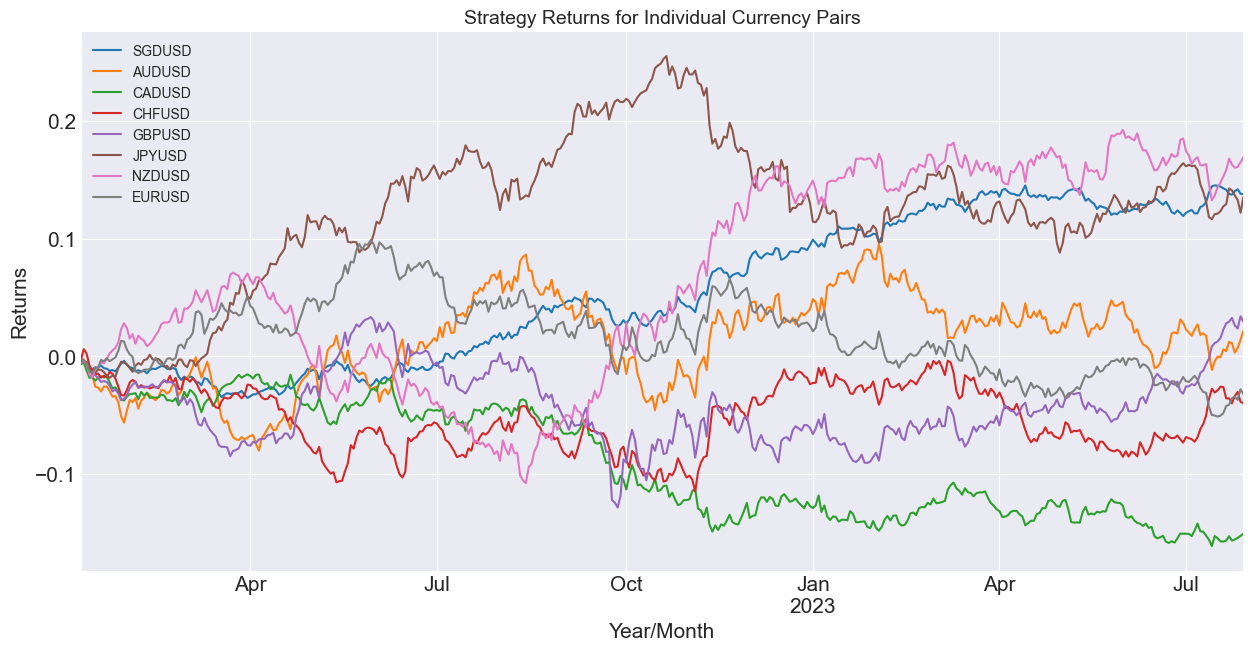

In [10]:
# Import matplotlib as an alias plt and set the style
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

# Plot the strategy returns
strategy_returns.cumsum().plot(figsize=[15, 7])

# Set the title and labels
plt.title('Strategy Returns for Individual Currency Pairs', fontsize=14)
plt.xlabel('Year/Month', fontsize=15)
plt.ylabel('Returns', fontsize=15)
plt.tick_params(axis='both', labelsize=15)

Now, we will plot the strategy returns for all the currency pairs combined

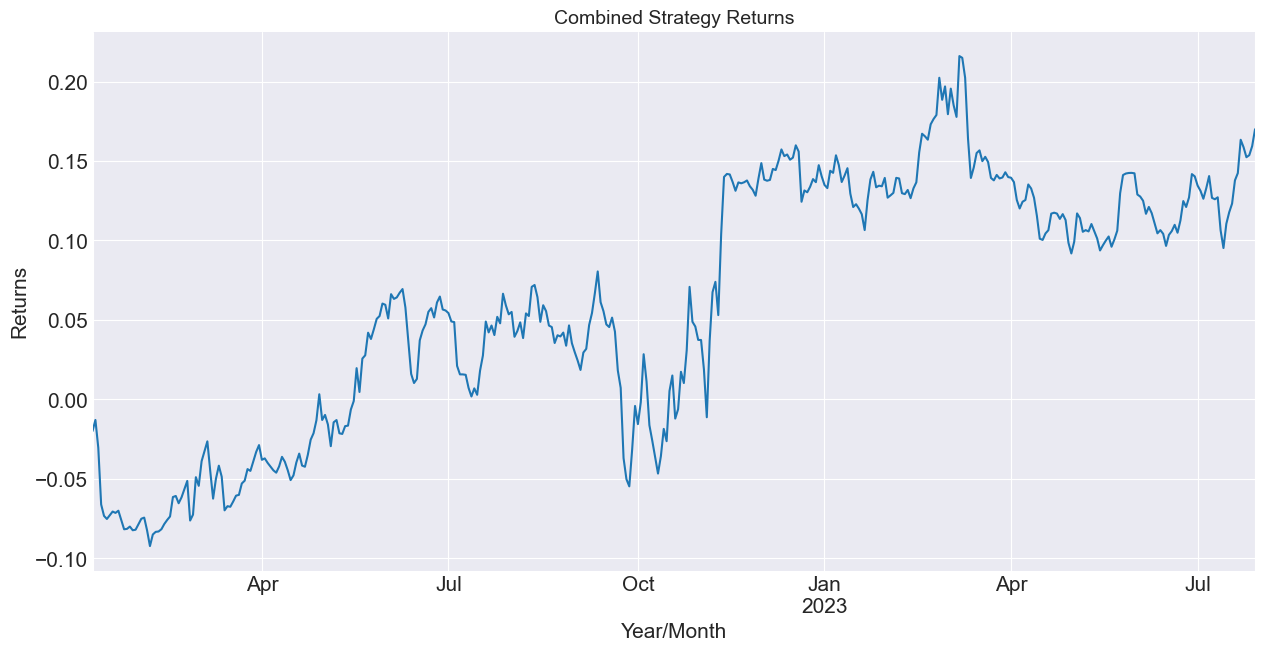

In [11]:
# Plot the combined strategy returns for all the currency pairs
leverage = 5.0
daily_ret = strategy_returns.sum(axis=1) / 8.0 * leverage
daily_ret.cumsum().plot(figsize=[15, 7])

# Set the title and labels
plt.title('Combined Strategy Returns', fontsize=14)
plt.xlabel('Year/Month', fontsize=15)
plt.ylabel('Returns', fontsize=15)
plt.tick_params(axis='both', labelsize=15)

<a id='analyse'></a> 
## Analyse the Performance
We compute the annualised Sharpe ratio, CAGR, and Maximum Drawdown of the strategy.

In [12]:
# The below function returns the Sharpe ratio for the daily strategy returns passed to it
import numpy as np
def annualized_sharpe_ratio(returns, N=252):
    return np.sqrt(N) * returns.mean() / returns.std()

# The below function returns the CAGR.
def CAGR(returns):
    cumulative_returns = returns.cumsum().iloc[-1]
    period_in_days = len(returns)
    return 100*((cumulative_returns+1)**(252.0/period_in_days)-1)


# Calculate the cumulative returns of the combined strategy
def maximum_drawdown(daily_ret):
    cumulative_returns = daily_ret.cumsum()

    # Compute the peak values of the cumulative returns
    peak_values = cumulative_returns.cummax()

    # Compute the drawdown, which is the difference between cumulative returns and peak values
    drawdown = cumulative_returns - peak_values

    # Find the maximum drawdown
    return drawdown.min()
    
print('maximum_drawdown: {:.2f}%'.format(maximum_drawdown(daily_ret) * 100))

print('Sharpe Ratio: ', round(annualized_sharpe_ratio(daily_ret), 2))
print('CAGR: ', round(CAGR(daily_ret), 2))

maximum_drawdown: -13.52%
Sharpe Ratio:  0.58
CAGR:  10.23


Note: The strategy does not consider the commission and rollover charges for the currency pairs. For more realistic results it is advisable to include those charges while backtesting. In the next unit, there will be Interactive exercise. All the best!<BR><BR>
    